# VampPriorVAE on Colored MNIST

In [1]:
import sys

sys.path.append("../")

In [2]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project import get_dataset
# from vae_project import TrainerIWAE, IWAE

from vae_project import VampPriorVAE, VampPriorTrainer, VampPriorHook, get_dataset

In [3]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [4]:
bs = 128
train_dl = DataLoader(train_ds, bs, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)
xb, yb = next(iter(train_dl))

In [5]:
# K_train = 5  # importance samples during training
# K_eval = 50  # tighter bound for evaluation
seed = 42
latent_dim = 16
h_dim = 64
wd = 1e-4
channels = (3, 32, 64, 128)
epochs = 25
lr = 1e-3

# VampPrior-specific hyperparameters
num_components = 100  # Standard number for VampPrior
input_channels = 3    # RGB channels for colored MNIST
input_size = (32, 32) # Padded MNIST size (28+2+2=32)
use_pseudo_net = False  # False for direct parameters (faster), True for network generation
beta_start = 0.0      # Start with no KL weight
beta_end = 0.6        # End with full KL weight
beta_anneal_epochs = 25  # Anneal over first 10 epochs

random_seed(seed)
collate_fn = CollateWithTransforms(batch_tfms or [])

dl_kwargs = dict(collate_fn=collate_fn, num_workers=6, persistent_workers=True)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, **dl_kwargs)
val_dl = DataLoader(val_ds, batch_size=bs, **dl_kwargs)

# recon_dist = 'bce'

In [6]:
# model = IWAE(channels, input_size=(32, 32), latent_dim=latent_dim, h_dim=h_dim, recon_dist=recon_dist)
model = VampPriorVAE(
    encoder_or_channel_nums=channels,  # Channel configuration
    input_size=input_size,             # Image dimensions (32, 32)
    input_channels=input_channels,    # 3 for RGB colored digits
    latent_dim=latent_dim,             # Same latent dimension as IWAE
    num_components=num_components,    # VampPrior-specific: number of pseudo-inputs
    h_dim=h_dim,                       # Same hidden dimension as IWAE
    act_fn=nn.ReLU(), #nn.LeakyReLU(0.1),                  # Activation function
    out_act=nn.Sigmoid(),              # Output activation for [0,1] range
    normalize=False,                   # Keep as False for colored MNIST in [0,1]
    use_pseudo_net=use_pseudo_net,     # Whether to use network for pseudo-inputs
    device=default_device,              # Auto-detect device
)

✓ Model initialization validated successfully for colored MNIST


In [7]:
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
hooks = [
    MetricsHook(), 
    ProgressBarHook(),
    VampPriorHook(
        save_dir="./vampprior_results",  # Directory to save results
        save_every=5,                    # Save every 5 epochs
        device=default_device
    )
]

# trainer_config = dict(
#     K_train=K_train,
#     K_eval=K_eval,
#     model=model,
#     train_dl=train_dl,
#     valid_dl=val_dl,
#     optim=optimizer,
#     epochs=epochs,
#     hooks=hooks,
# )

# trainer = TrainerIWAE(**trainer_config)

# Calculate beta annealing steps
beta_anneal_steps = len(train_dl) * beta_anneal_epochs

# Initialize VampPrior trainer instead of IWAE trainer
trainer = VampPriorTrainer(
    model=model,
    train_dl=train_dl,
    valid_dl=val_dl,
    optim=optimizer,
    loss_func=None,  # Will use default vamp_prior_elbo_loss
    epochs=epochs,
    hooks=hooks,
    device=default_device,
    beta_start=beta_start,
    beta_end=beta_end,
    beta_anneal_steps=beta_anneal_steps,
)

In [8]:
trainer.fit()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 369.1529 | Val Loss: 206.7054


Epoch 2/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 24/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 159.9453 | Val Loss: 162.1319


Epoch 25/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 25/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 160.4515 | Val Loss: 161.9184
✓ Saved checkpoint at epoch 25


In [9]:
t.save(model, "./vampprior_results/vp_vae_model.pt")

array([<Axes: title={'center': 'Loss'}, xlabel='Batch / Step'>],
      dtype=object)

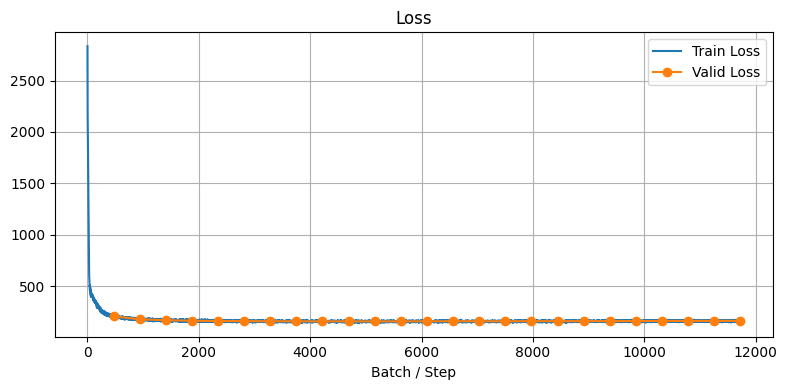

In [10]:
trainer.get_hook(MetricsHook).plot_loss()

Text(0.5, 1.0, 'Inputs')

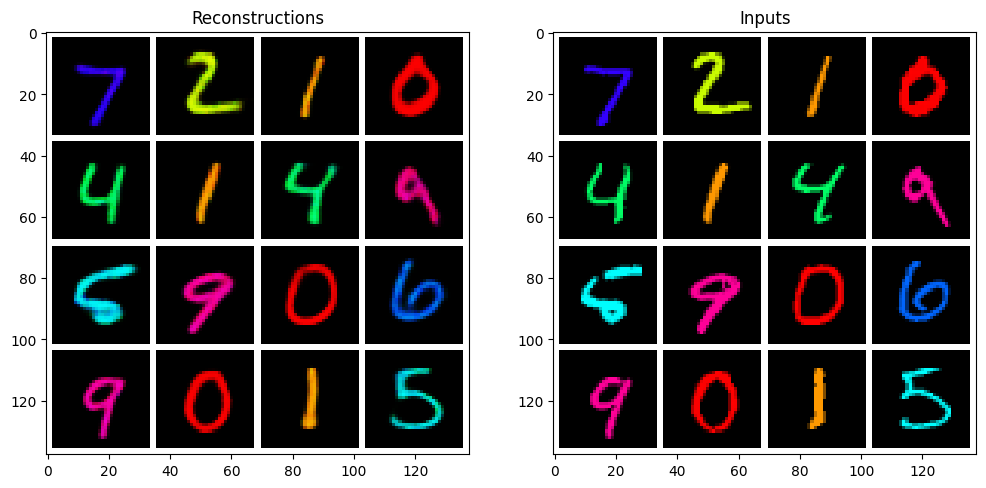

In [25]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16].to(default_device)
# recon = trainer.predict(x) #, training=False)
with torch.no_grad():
    recon, _, _ = model(x) 
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon, axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

### Samples

<Axes: >

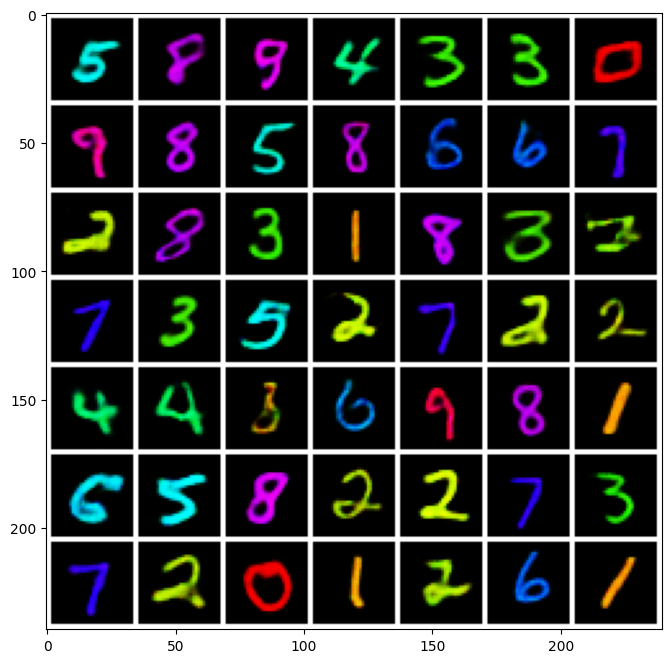

In [26]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(trainer.model.sample(49), ax=ax)

## FID, KID and other scores

In [28]:
!pip install torch_fidelity

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [30]:
from vae_project.evaluate import evaluate_model
# have to use this slower dataset to match api of torch_fidelity
ds = ColoredMNIST('../data', train=False, color_type='label', download=True)
metrics = evaluate_model(model, ds)
metrics

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.68MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 256kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.09MB/s]
Creating feature extractor "inception-v3-compat" with features ['logits_unbiased', '2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /home/llm_reliability/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 50.6MB/s]
Extracting features from input1
Processing samples                                                           
Extracting features from input2
Processing samples                                                            
Inception Score: 1.845314957023221 ± 0.02847936624515302
Frechet Inception Distance: 165.19142601957938
Kernel Inception Distance: 0.15887447118759154 ± 0.002540051441620014            


{'inception_score_mean': 1.845314957023221,
 'inception_score_std': 0.02847936624515302,
 'frechet_inception_distance': 165.19142601957938,
 'kernel_inception_distance_mean': 0.15887447118759154,
 'kernel_inception_distance_std': 0.002540051441620014}

## Langevin dynamics

In [33]:
from vae_project import langevin_dynamics

In [34]:
from vae_project.utils import show_imgs

def compare_dynamics(model, xb, n_steps=100, step_sz=0.1):
    orig, refined, _ = langevin_dynamics(model, xb, n_steps=n_steps, step_sz=step_sz)
    
    # Visual Comparison
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    show_imgs(xb.cpu(), ax=ax1, title="Original Input")
    show_imgs(orig.cpu(), ax=ax2, title="Standard Reconstruction")
    show_imgs(refined.cpu(), ax=ax3, title=f"Langevin Reconstruction ({n_steps} steps)")
    for a in (ax1, ax2, ax3): a.axis('off')
    plt.show()

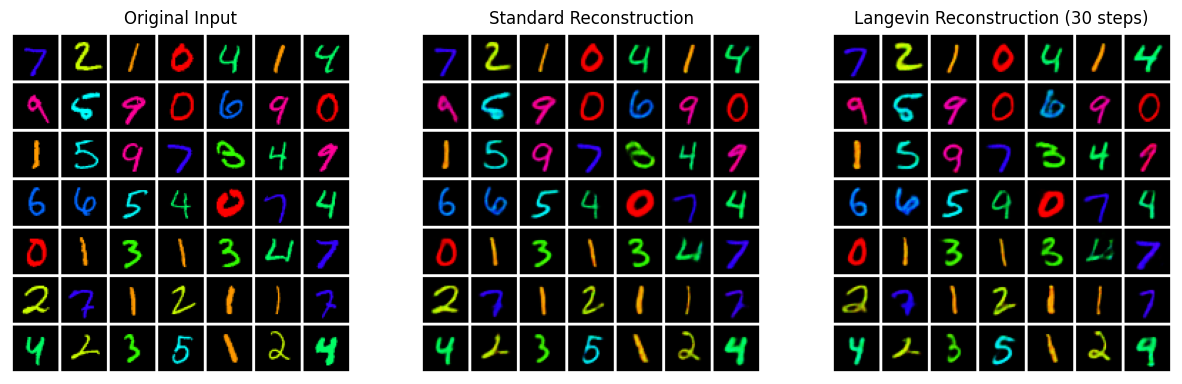

In [35]:
compare_dynamics(model, to_device(xb[:49],trainer.device), n_steps=30, step_sz=0.02)

In [36]:
x = xb[:49].to(trainer.device)
x_orig, x_ref, z_final, hist_b = langevin_dynamics(model, x, n_steps=100, return_hist=True, step_sz=0.02)

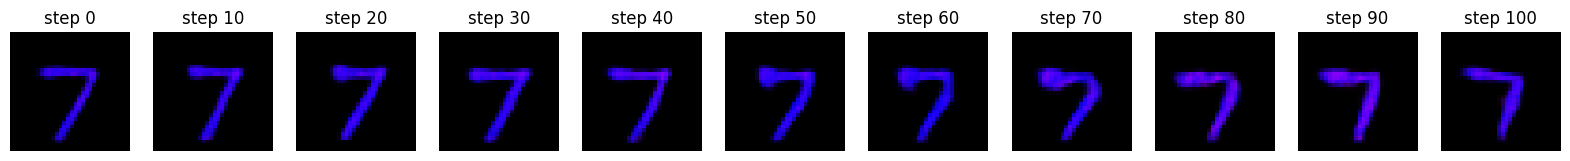

In [37]:
hist = hist_b[0]
steps_idx = np.arange(len(hist), step=10, dtype=np.int32)
steps = hist[steps_idx]
decoded_steps = [model.decode(z.to(trainer.device))[0] for z in steps]

fig, axes = plt.subplots(1, len(decoded_steps), figsize=(20, 2))
for ax, i, img in zip(axes, steps_idx, decoded_steps):
    show_img(img.cpu(), ax, title=f'step {i}')
    ax.axis('off')
plt.show()

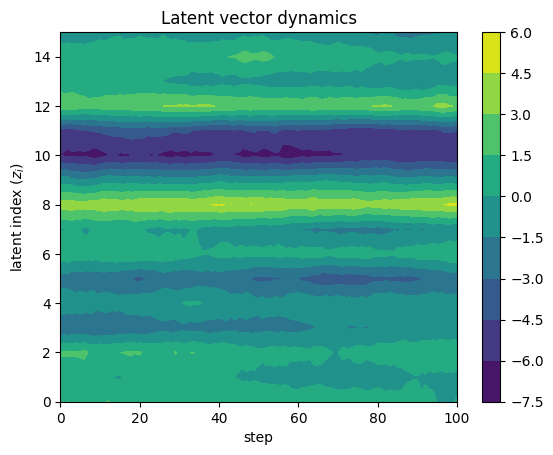

In [38]:
plt.contourf(hist.T)
plt.xlabel('step')
plt.ylabel('latent index ($z_i$)')
plt.title("Latent vector dynamics")
plt.colorbar()

In [39]:
from IPython.display import display, Image as IPImage
from PIL import Image

def animate_langevin(hist, fn='langevin.gif', fps=20, scale=5):
    with t.no_grad():
        z_seq = hist.to(trainer.device)
        frames = model.decode(z_seq)
    frames = F.interpolate(frames.cpu(), scale_factor=scale, mode='nearest')
    if frames.min() < 0: frames = (frames + 1) / 2
    frames = frames.clamp(0, 1).mul(255).byte().permute(0, 2, 3, 1)
    imgs = [Image.fromarray(f) for f in frames.numpy()]
    
    imgs[0].save(fn, save_all=True, append_images=imgs[1:], duration=1000//fps, loop=0)
    print(f"Saved animation to {fn}")
    return display(IPImage(filename=fn))

Saved animation to ./vampprior_results/vp_vae_langevin.gif


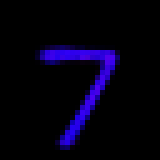

In [40]:
animate_langevin(hist, fn="./vampprior_results/vp_vae_langevin.gif")